# Compressed Predictive Information Coding
This is a demo of how the CPIC package can be used in a plug-and-play fashion on real time-series datasets.

In [1]:
import os, urllib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge as RR
from sklearn.metrics import r2_score
import torch
from torch.utils.data import DataLoader

from dca.data_util import load_sabes_data
from dca import DynamicalComponentsAnalysis as DCA
from cpic import CPIC
from cpic.utils.data import PastFutureDataset

In [2]:
print(np.__version__)

1.26.4


In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available(): # For Apple Silicon
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


# About the Data
The data used is from the Sabes Lab, consisting of recordings from the primary motor cortex (M1) of the subject "Indy", performing a continuous grid-based reaching task of different locations on a grid. This is the same data used in the DCA and CPIC paper. In this tutorial, we won't cross validate the results as was done in the paper to keep things simple.

More information and the data can be found here:

O'Doherty, Joseph E., Cardoso, Mariana M. B., Makin, Joseph G., & Sabes, Philip N. (2017). Nonhuman Primate Reaching with Multichannel Sensorimotor Cortex Electrophysiology. *Zenodo*. http://doi.org/10.5281/zenodo.583331

**Note:** The file is 1.1 GB, so it may take a few minutes to download. 

In [4]:
fname = 'indy_20160627_01.mat'
if not os.path.isfile(f"./data/{fname}"): # check if file was already downloaded
    tmp = f"./data/{fname}_tmp"
    urllib.request.urlretrieve('https://zenodo.org/record/583331/files/indy_20160627_01.mat?download=1', tmp)
    os.rename(tmp, fname)

In [5]:
data = load_sabes_data(f"./data/{fname}", bin_width_s=.05)

We'll use 50ms bins and preprocess the data by removing neurons with very low firing rates, square-root transforming the spike counts, and high-pass filtering the data to remove slow nonstationarity (30s timescale).

This should load a dictionary that contains the (preprocessed) spike counts for 109 neurons along with the cursor location sampled at the same rate. We'll visualize the spike raster and cursor location for 1 minute of data.

In [6]:
keys = data.keys()
print(data.keys())
print(*[(key, data[key].shape) for key in keys])

dict_keys(['M1', 'cursor'])
('M1', (67258, 109)) ('cursor', (67258, 2))


In [7]:
X = data['M1']
Xn = X / X.std(axis=0, keepdims=True) # normalized version will be used later
Y = data['cursor']

Text(0, 0.5, 'cursor y')

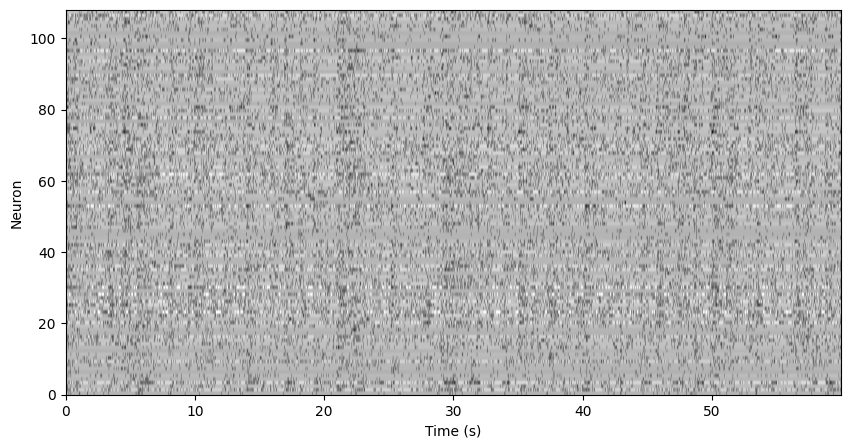

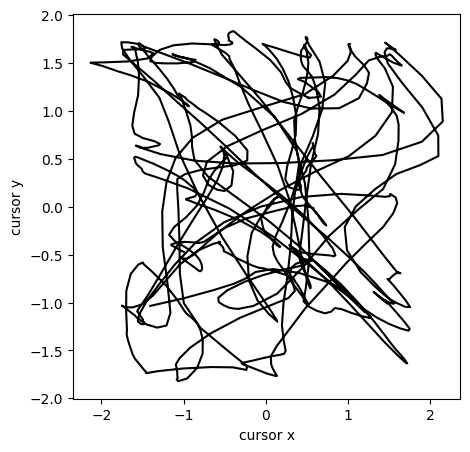

In [8]:
plt.figure(figsize=(10, 5))
plt.imshow(X[:1200].T, extent=[0, 1199*.05, 0, 108], cmap='gray_r', aspect='auto')
plt.xlabel('Time (s)')
plt.ylabel('Neuron')

plt.figure(figsize=(5, 5))
plt.plot(*Y[:1200].T, c='k')
plt.xlabel('cursor x')
plt.ylabel('cursor y')

# What is the dimensionality of the neural data?
There are many ways of defining dimensionality. PCA organizes the data along projections of descending variance explained. If the variance of your dataset is confined to a lower dimensional subspace in the original measurement space, PCA will find this manifold. DCA, on the other hand, looks for subspaces with highly predictive dynamics, as measured by Predictive Information (PI). CPIC additionally will optimize on compression constraints to find the smallest subspace with the most predictive dynamics.

We'll focus on the first 30 dimensions, but you could extend the analysis out to 109. We'll look at the objective of PCA (variance explained), DCA (PI) as a function of projection dimensionality, and CPIC (PI). This is a purely unsupervised analysis of dimensionality. We can also ask how well the projections (found in an unsupervised manner) can be used to predict behavior for each method.

One weakness of PCA, which motivated the development of DCA, is that it cannot distinguish high variance dynamics from high variance noise. Let's first look at the variance explained by PCA projections and their $R^2$ in predicting the behavioral data. We'll also plot the max $R^2$ for a fully supervised linear method at each dimensionality.

In [9]:
max_dim = 30
lag = 4 # 200ms lag for the neural data for predicting behavior

Text(0, 0.5, '0-1 normalized metric')

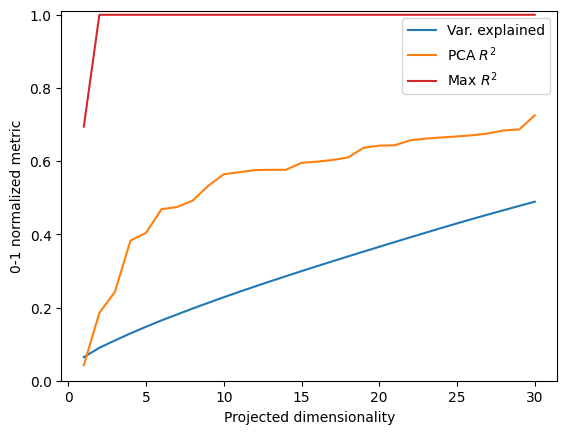

In [10]:
ds = np.arange(1, max_dim+1)
pca_model = PCA()
pca_model.fit(X)
var = np.sum(pca_model.explained_variance_)

pca1_scores = np.zeros(ds.size)
max_scores = np.zeros(ds.size)
for ii, d in enumerate(ds):
    Xd = pca_model.transform(X)[:, :d]
    rr_model = RR(alpha=1e-6)
    rr_model.fit(Xd[:-lag], Y[lag:])
    pca1_scores[ii] = r2_score(Y[lag:], rr_model.predict(Xd[:-lag]))
rr_model = RR(alpha=1e-6)
rr_model.fit(X[:-lag], Y[lag:])
max_scores[:] = r2_score(Y[lag:], rr_model.predict(X[:-lag]))
u, s, v = np.linalg.svd(rr_model.coef_)
for ii, d in enumerate(range(1, Y.shape[1])):
    rr_model.coef_ = (u[:, :d] * s[:d]) @ v[:d]
    max_scores[ii] = r2_score(Y[lag:], rr_model.predict(X[:-lag]))


plt.plot(ds, np.cumsum(pca_model.explained_variance_)[:ds.size] / var, label='Var. explained', c='C0')
plt.ylim(0, 1.01)
plt.plot(ds, pca1_scores / max_scores[-1], label=r'PCA $R^2$', c='C1')
plt.plot(ds, max_scores / max_scores[-1], label=r'Max $R^2$', c='C3')
plt.legend(loc='best')
plt.xlabel('Projected dimensionality')
plt.ylabel('0-1 normalized metric')

To make visualization easier, we've normalized the y-axis so that 1 is the value of the metric at the full dimensionality of the dataset (109). So, all plots would eventually go to 1 at $d=109$.

We can run the equivalent analysis for DCA and CPIC. Rather than explained variance, we'll look at PI. This analysis will be take longer since the projections need to be re-fit (trained for CPIC) for each dimensionality.

CPIC improves upon DCA on the basis that...

In [11]:
dca_pi = np.zeros(ds.size)
dca_scores = np.zeros(ds.size)
dca_model = DCA(T=10, d=X.shape[1])
dca_model.estimate_data_statistics(X) # only need to estimate this once
dca_max_pi = dca_model.score() # PI of data with no dimensionality reduction

In [12]:
for ii, d in enumerate(ds):
    print(f"d = {d}")
    dca_model.fit_projection(d=d)
    dca_pi[ii] = dca_model.score()

d = 1
d = 2
d = 3
d = 4
d = 5
d = 6
d = 7
d = 8
d = 9
d = 10
d = 11
d = 12
d = 13
d = 14
d = 15
d = 16
d = 17
d = 18
d = 19
d = 20
d = 21
d = 22
d = 23
d = 24
d = 25
d = 26
d = 27
d = 28
d = 29
d = 30


In [ ]:
cpic_pi = np.zeros(ds.size)
dataset = PastFutureDataset([X], window_size=10)

for ii, d in enumerate(ds):
    print(f"ydim = {d}")

    model = CPIC(ydim=d, T=10, device=device)
    model.to(device)

    model.fit(dataset, epochs=10)

    # evaluate predictive bound over dataset
    total_pi = 0
    count = 0

    loader = DataLoader(dataset, batch_size=256, shuffle=False)

    for X_past, X_future in loader:
        loss, I_compress, I_predictive = model.score(
            X_past.float().to(device),
            X_future.float().to(device)
        )
        total_pi += I_predictive
        count += 1

    cpic_pi[ii] = total_pi / count

ydim = 1


 10%|█████████████████▋                                                                                                                                                               | 1/10 [00:08<01:12,  8.10s/it]

Epoch 0: loss=-0.0007, I_compress_bound=0.6699, I_predictive_bound=0.0014


 20%|███████████████████████████████████▍                                                                                                                                             | 2/10 [00:16<01:06,  8.28s/it]

Epoch 1: loss=-0.2093, I_compress_bound=2.8069, I_predictive_bound=0.2122


...

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [01:28<00:00,  8.89s/it]

Epoch 9: loss=-1.7698, I_compress_bound=4.1584, I_predictive_bound=1.7740


ydim = 18


 10%|█████████████████▋                                                                                                                                                               | 1/10 [00:09<01:24,  9.41s/it]

Epoch 0: loss=0.0048, I_compress_bound=3.9256, I_predictive_bound=-0.0008


In [ ]:
uncompressed_model = CPIC(ydim=109, T=10, device=device)
uncompressed_model.to(device)

uncompressed_model.fit(dataset, epochs=10, early_stop=5)

# evaluate predictive bound over dataset
total_pi = 0
count = 0

loader = DataLoader(dataset, batch_size=256, shuffle=False)

for X_past, X_future in loader:
    loss, I_compress, I_predictive = uncompressed_model.score(
        X_past.float().to(device),
        X_future.float().to(device)
    )
    total_pi += I_predictive
    count += 1

cpic_max_pi = total_pi / count

## PI (normalized) vs. Latent Dimension

In [ ]:
plt.figure()
plt.plot(ds, dca_pi / dca_max_pi, label="DCA")
plt.plot(ds, cpic_pi / cpic_max_pi, label="CPIC")
plt.xlabel("Latent dimensionality d")
plt.ylabel("Normalized Predictive Information")
plt.title("PI Saturation Curve")
plt.legend()
plt.ylim(0, 1.01)
plt.show()

- CPIC seems to be more predicition-efficient than DCA; predictive sturcutre is highly compressible, CPIC finds predictive modes earlier, DCA spreads predictive power across more dimension
- Next time train over more epochs (likely causing the instability in low dimension compression)
  
**Future Steps:** Duffing oscillator, logistic map, Lorenz attractor